In [1]:
from utils import *
import pandas as pd
import os
import numpy as np

In [2]:
# Discretize data

file_path = os.path.join("tables", "exerciseTableForBN_python.parquet")
exerciseTable = pd.read_parquet(file_path)

colsToRemove = ["PtID", "DeviceDtTm", "UTCDtTm", "ExerciseName", "DistanceValue", "DistanceUnits", "DurationUnits", "EnergyValue",
                 "EnergyUnits", "TmZnOffset", "CleanActivityName", "AOB", "CWL", "TimeSinceLastBolus", "LastBolus", 
                 "TimeSinceLastBasal", "LastBasal"]

df = exerciseTable.copy()

df_discrete = discretize_data(df, 
    cv_strategy = "clinical",
    bmi_strategy = "clinical",
    hba1c_strategy = "clinical", 
    glucose_strategy = "clinical", 
    cols_to_remove = colsToRemove)

Discretizing features | CV: clinical | BMI: clinical | HbA1c: clinical | Glucose: clinical
Discretization complete.


/opt/homebrew/lib/python3.10/site-packages/numpy/lib/function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


In [3]:
# Define features and tiers

tiers = {
    'static': ['age', 'gender', 'BMI', 'HbA1c', 'InsSensitivity', 'InsCarbRatio'],
    'pre': ['preExerciseRoc', 'startExerciseGlucoseLevel', 'preExerciseGlucoseCV', 'IOB', 'COB'],
    'exercise': ['MET_min', 'ACWR'],
    'outcome_during': ['exerciseGlucoseRoc'],
    'outcome_post': ['minGlucosePostExercise', 'postExerciseTIR', 'postExerciseGlucoseCV']
}

features_to_drop = ["height", "weight", "DurationValue", "MET", "EnergyPerMinute", "exerciseGlucoseExcursion"]

In [4]:
# Prepare Data & Check Discretization

df_clean = prepare_data(df_discrete, features_to_drop)

check_discretization(df_clean) # comment if not needed!

Data prepped. Missing values: 0

--- DISCRETIZATION HEALTH CHECK ---
📊 Feature: MET_min
      High: 32.0%
      Low: 32.0%
      Medium: 32.0%
   ⚠️ Unknown: 3.9%
------------------------------
📊 Feature: age
      Middle: 39.6%
      Younger: 36.4%
      Older: 24.0%
------------------------------
📊 Feature: gender
      female: 66.5%
      male: 33.5%
------------------------------
📊 Feature: HbA1c
      Prediabetes: 42.4%
      Diabetes - Control: 26.8%
      Normal: 16.2%
      Diabetes - Poor Control: 14.7%
------------------------------
📊 Feature: ACWR
      Sedentary: 23.1%
      Highly Active: 23.0%
      Active: 23.0%
      Lightly Active: 23.0%
      Unknown: 7.8%
------------------------------
📊 Feature: COB
      Low: 25.0%
      High: 25.0%
      Moderate: 25.0%
      Very High: 25.0%
   ⚠️ Unknown: 0.0%
------------------------------
📊 Feature: BMI
      Normal: 58.7%
      Overweight: 34.2%
   ⚠️ Underweight: 3.6%
   ⚠️ Obese: 3.5%
   ⚠️ Unknown: 0.0%
-------------------

In [ ]:
# Analyze Unknown Sources

analyze_unknown_sources(df, df_clean)

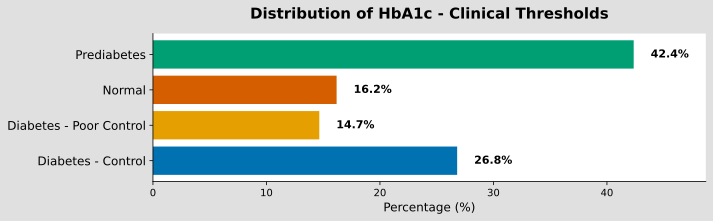

In [5]:
# Visualize Feature Distribution after Discretization

target_feature = "HbA1c"

# Plot the Raw Clinical thresholds
plot_single_feature_distribution(df_clean, target_feature, title_prefix="- Clinical Thresholds")



🔨 Collapsing sparse bins to optimize the Bayesian Network...
✅ Bin collapsing complete! Dataset is mathematically safe.


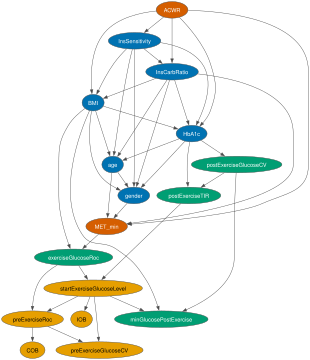

In [7]:
# Data Driven BN

collapse = True

if(collapse):
    df_clean_collapsed = collapse_sparse_bins(df_clean) # comment if you want to use the original discretization for the constrained model!
    learner_data_driven = gum.BNLearner(df_clean_collapsed)
else:
    learner_data_driven = gum.BNLearner(df_clean)

learner_data_driven.useGreedyHillClimbing()
bn_data_driven = learner_data_driven.learnBN()

visualize_network(bn_data_driven, tiers)

In [ ]:
# Visualize Feature Distribution after Discretization and Bins Collapse

target_feature = "preExerciseGlucoseCV"

# Plot the Raw Clinical thresholds
plot_single_feature_distribution(df_clean_collapsed, target_feature, title_prefix="- Clinical Thresholds After Merge")

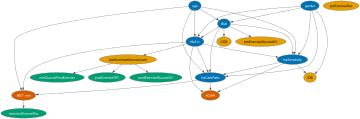

In [9]:
# Constrained BN

collapse = False

if(collapse):
    df_clean_collapsed = collapse_sparse_bins(df_clean) # comment if you want to use the original discretization for the constrained model!
    learner_constrained = gum.BNLearner(df_clean_collapsed)
else:
    learner_constrained = gum.BNLearner(df_clean)
    
learner_constrained.useGreedyHillClimbing()
learner_constrained = apply_expert_constraints(learner_constrained, tiers)
bn_constrained = learner_constrained.learnBN()

visualize_network(bn_constrained, tiers)